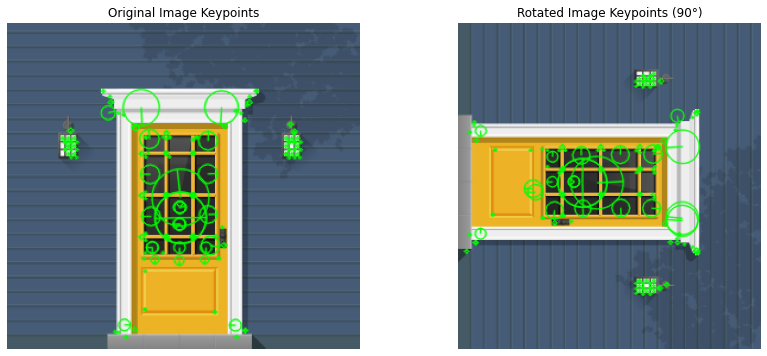

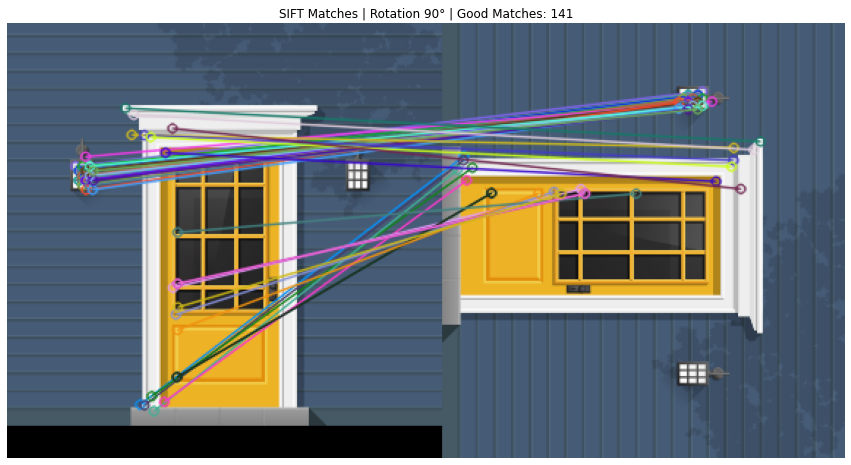

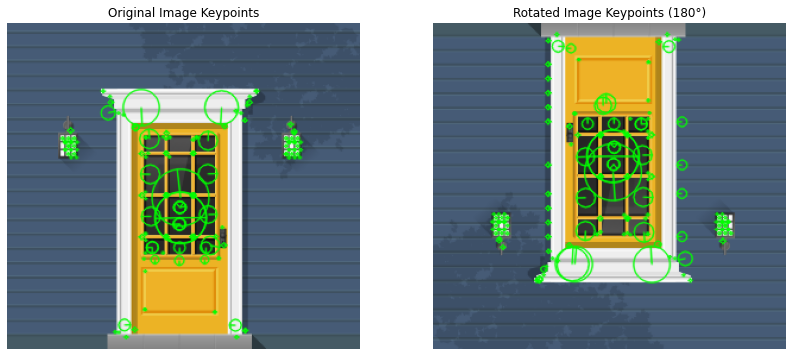

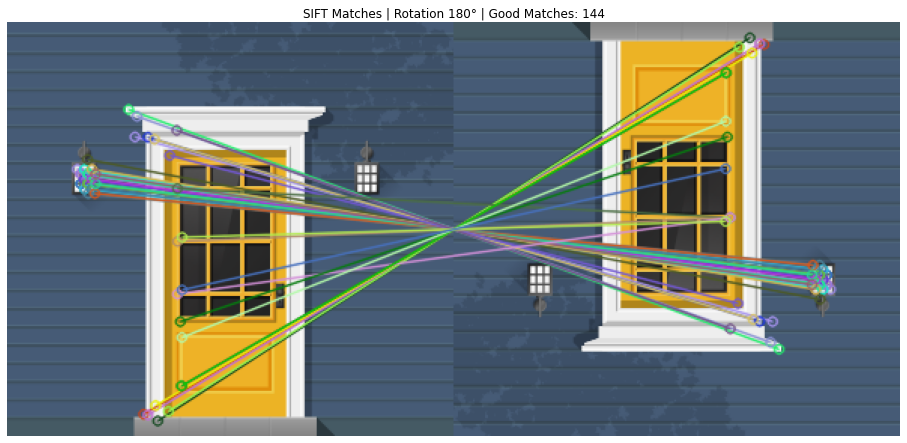

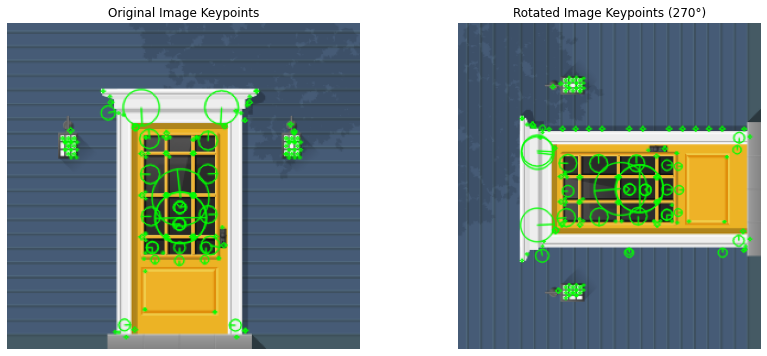

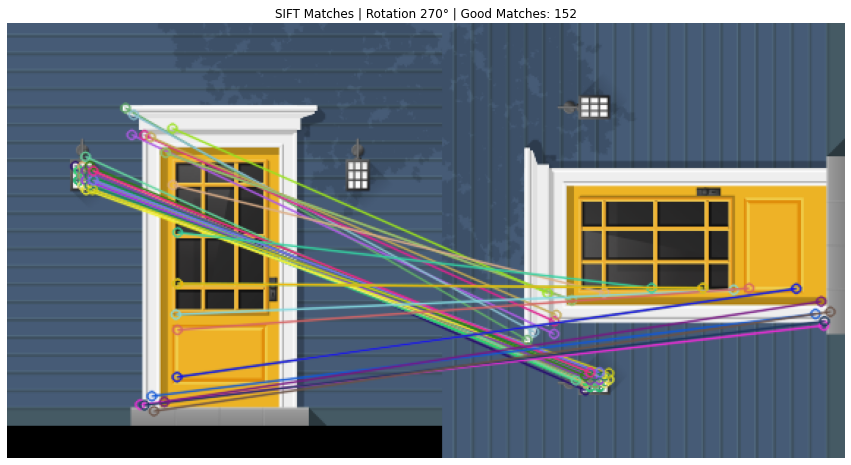

,Rotation Angle,Keypoints (Original),Keypoints (Rotated),Total Matches,Good Matches (Ratio Test)
0,90°,168,162,168,141
1,180°,168,170,168,144
2,270°,168,179,168,152


In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# =========================
# 1. خواندن تصویر اصلی
# =========================
img = cv2.imread('images/img1.png')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# =========================
# 2. تعریف چرخش‌ها
# =========================
rotations = {
    '90°': cv2.ROTATE_90_CLOCKWISE,
    '180°': cv2.ROTATE_180,
    '270°': cv2.ROTATE_90_COUNTERCLOCKWISE
}

# =========================
# 3. SIFT و Matcher
# =========================
sift = cv2.SIFT_create()
bf = cv2.BFMatcher(cv2.NORM_L2)

kp1, des1 = sift.detectAndCompute(img_rgb, None)

# =========================
# 4. لیست ذخیره نتایج
# =========================
results = []

for angle, rot_code in rotations.items():
    
    img_rot = cv2.rotate(img_rgb, rot_code)
    kp2, des2 = sift.detectAndCompute(img_rot, None)
    
    matches = bf.knnMatch(des1, des2, k=2)
    
    good_matches = []
    for m, n in matches:
        if m.distance < 0.75 * n.distance:
            good_matches.append(m)
    
    # ذخیره نتایج برای جدول
    results.append({
        'Rotation Angle': angle,
        'Keypoints (Original)': len(kp1),
        'Keypoints (Rotated)': len(kp2),
        'Total Matches': len(matches),
        'Good Matches (Ratio Test)': len(good_matches)
    })
    
    # =========================
    # رسم نقاط کلیدی روی تصاویر جداگانه
    # =========================
    img_kp_orig = cv2.drawKeypoints(
        img_rgb, kp1, None, color=(0,255,0), flags=cv2.DrawMatchesFlags_DRAW_RICH_KEYPOINTS
    )
    img_kp_rot = cv2.drawKeypoints(
        img_rot, kp2, None, color=(0,255,0), flags=cv2.DrawMatchesFlags_DRAW_RICH_KEYPOINTS
    )
    
    plt.figure(figsize=(14,6))
    plt.subplot(1,2,1)
    plt.imshow(img_kp_orig)
    plt.title('Original Image Keypoints')
    plt.axis('off')
    
    plt.subplot(1,2,2)
    plt.imshow(img_kp_rot)
    plt.title(f'Rotated Image Keypoints ({angle})')
    plt.axis('off')
    
    plt.show()
    
    # =========================
    # رسم تطبیق‌ها بین تصویر اصلی و چرخیده
    # =========================
    img_match = cv2.drawMatches(
        img_rgb, kp1,
        img_rot, kp2,
        good_matches[:50],
        None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )
    
    plt.figure(figsize=(16,8))
    plt.imshow(img_match)
    plt.title(f'SIFT Matches | Rotation {angle} | Good Matches: {len(good_matches)}')
    plt.axis('off')
    plt.show()

# =========================
# 5. ساخت جدول مقایسه‌ای
# =========================
df_results = pd.DataFrame(results)
df_results
